# Complex Numbers — Lecture 7
## Cube Roots of Unity: $1, \omega, \omega^2$ · Properties · Geometry · Cube Factorisations · Series Question

**Source:** [Complex Numbers 07 | Cube Roots of Unity | Class 11 | JEE](https://youtu.be/JZCqOseSe0E), Physics Wallah (Class 11), about 53 min

**Prerequisite:** Lectures 1–5 (quadratic formula with $\sqrt{-3} = \sqrt3\,i$, conjugate, modulus, argument, Euler form).

### What this lecture covers
1. What "roots of unity" means ($a^{1/n}$ is the $n$-th root of $a$, and **unity** $= 1$)
2. **Solving $x^3 = 1$:** three answers, $1$, $\omega$ and $\omega^2$
3. **Properties:**
   - $\omega$ and $\omega^2$ are conjugates
   - all three have $|\cdot| = 1$
   - $1 + \omega + \omega^2 = 0$
   - $\omega^3 = 1$
   - $1 + \omega^p + \omega^{2p} \in \{0, 3\}$
4. **Geometry:**
   - they sit on the unit circle and form an **equilateral triangle** with side $\sqrt3$
   - the roots are in **GP**, and their arguments are in **AP**
5. **Factorisations:** $a^3 \pm b^3$ and $a^3 + b^3 + c^3 - 3abc$ in terms of $\omega$
6. **Square and fourth roots of unity**, and a preview of $n$-th roots
7. **Question:** $\displaystyle\sum (r - 1)(r - \omega)(r - \omega^2)$

> *"Just as rays complete the sun and fragrance completes the breeze, complex numbers are incomplete without the cube roots of unity."* The lecturer calls them **the heartbeat of complex numbers**.

Sections marked *(extra)* go beyond what was said in the lecture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Same look as Lectures 1–6
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "animation.embed_limit": 30,
})
rng = np.random.default_rng(7)

def argand(ax, lim=2.5, ticks=1):
    # Draw the complex plane: real axis horizontal, imaginary axis vertical
    ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    t = np.arange(ticks, lim, ticks); t = np.r_[-t[::-1], 0, t]
    ax.set_xticks(t)
    ax.set_yticks(t, ["0" if v == 0 else "i" if v == 1 else "−i" if v == -1 else f"{v:g}i".replace("-", "−") for v in t])
    ax.set_xlabel("Re"); ax.set_ylabel("Im")

def arrow(ax, z0, z1, color, lw=2, ls="-"):
    z0, z1 = complex(z0), complex(z1)
    ax.annotate("", (z1.real, z1.imag), (z0.real, z0.imag),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, ls=ls, mutation_scale=14, shrinkA=0, shrinkB=0))

def unit_circle(ax, color=GRID, lw=1.5):
    c = np.linspace(0, 2*np.pi, 300); ax.plot(np.cos(c), np.sin(c), color=color, lw=lw)

w = (-1 + np.sqrt(3)*1j)/2          # ω, the standard choice
ROOTS = [1 + 0j, w, w**2]
print("ω =", w, "   ω² =", w**2)

ω = (-0.5+0.8660254037844386j)    ω² = (-0.4999999999999999-0.8660254037844386j)


---
## 1. What Are "Roots of Unity"?

**Notation for roots:**
$$a^{1/2} = \sqrt a \text{ (square root)}, \qquad a^{1/3} = \sqrt[3]{a} \text{ (cube root)}, \qquad a^{1/4} \text{ (fourth root)}, \qquad a^{1/n} \text{ ($n$-th root, } n \in \mathbb{N})$$

**Unity** means the number $1$. So the **cube roots of unity** are the values of
$$1^{1/3}$$
Note the plural, **roots**. As children we'd say $1^{1/3} = 1$ and stop. After studying complex numbers we know better: there are **three** answers.

---
## 2. Solving $x^3 = 1$

Let $x = 1^{1/3}$. Cubing both sides gives
$$x^3 = 1 \;\Longrightarrow\; x^3 - 1 = 0$$
Write $1 = 1^3$ and use $a^3 - b^3 = (a - b)(a^2 + ab + b^2)$:
$$(x - 1)(x^2 + x + 1) = 0$$
**Either** $x - 1 = 0$, so $x = 1$.

**Or** $x^2 + x + 1 = 0$. By the quadratic formula $x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$:
$$x = \frac{-1 \pm \sqrt{1 - 4}}{2} = \frac{-1 \pm \sqrt{-3}}{2} = \frac{-1 \pm \sqrt3\,i}{2}$$
using $\sqrt{-3} = \sqrt3\cdot\sqrt{-1} = \sqrt3\,i$.

$$\boxed{1^{1/3} \in \left\{\;1,\quad -\frac12 + \frac{\sqrt3}{2}i,\quad -\frac12 - \frac{\sqrt3}{2}i\;\right\}}$$
**One real** root and **two non-real (complex)** roots. Cube any of the three and you get exactly $1$.

In [2]:
cand = [1 + 0j, -0.5 + np.sqrt(3)/2*1j, -0.5 - np.sqrt(3)/2*1j]
for z in cand:
    print(f"x = {z.real:+.4f} {z.imag:+.4f}i    x³ = {np.round(z**3, 12)}")
print("\nnumpy roots of x³ − 1:", np.round(np.roots([1, 0, 0, -1]), 6))

x = +1.0000 +0.0000i    x³ = (1+0j)
x = -0.5000 +0.8660i    x³ = (1+0j)
x = -0.5000 -0.8660i    x³ = (1-0j)

numpy roots of x³ − 1: [-0.5+0.866025j -0.5-0.866025j  1. +0.j      ]


### Picture *(extra)*: why we never "saw" the other two roots
On the real number line, $y = x^3 - 1$ crosses zero **only once**, at $x = 1$. The quadratic factor $x^2 + x + 1$ never touches zero for real $x$ (its discriminant is $-3 < 0$). The two missing roots live **off** the real line, in the complex plane.

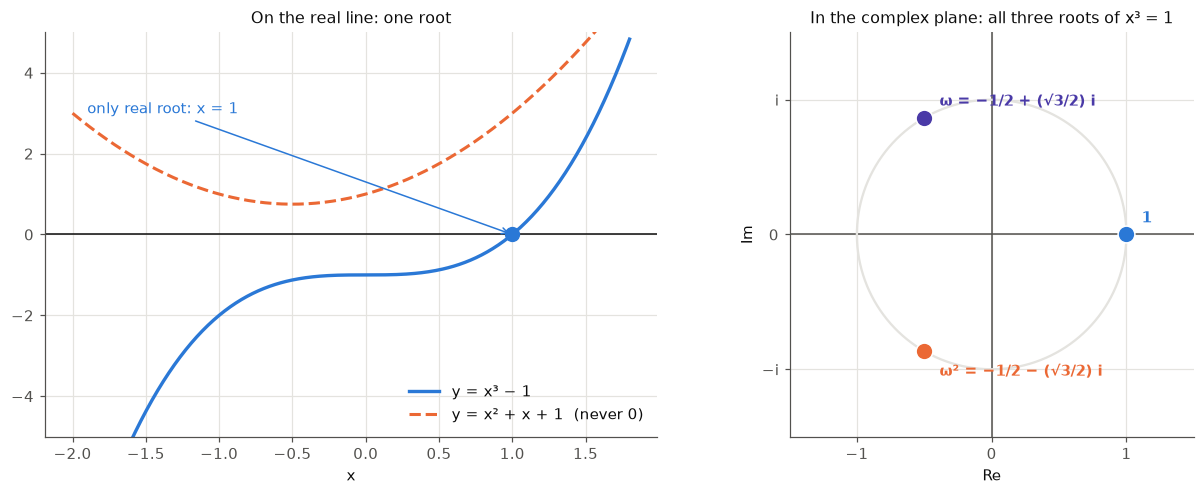

In [3]:
x = np.linspace(-2, 1.8, 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
ax = axes[0]
ax.plot(x, x**3 - 1, color=BLUE, lw=2.2, label="y = x³ − 1")
ax.plot(x, x**2 + x + 1, color=ORANGE, lw=2, ls="--", label="y = x² + x + 1  (never 0)")
ax.axhline(0, color=INK, lw=1); ax.plot(1, 0, "o", color=BLUE, ms=9)
ax.annotate("only real root: x = 1", (1, 0), xytext=(-1.9, 3), arrowprops=dict(arrowstyle="->", color=BLUE), color=BLUE)
ax.set_ylim(-5, 5); ax.set_xlabel("x"); ax.legend(frameon=False, loc="lower right"); ax.set_title("On the real line: one root", fontsize=10.5)
ax = axes[1]; argand(ax, lim=1.5)
unit_circle(ax)
for z, lab, c in zip(ROOTS, ["1", "ω = −1/2 + (√3/2) i", "ω² = −1/2 − (√3/2) i"], [BLUE, VIOLET, ORANGE]):
    ax.plot(z.real, z.imag, "o", color=c, ms=11, mec="white", zorder=5)
    ax.annotate(lab, (z.real, z.imag), xytext=(10, 8 if z.imag >= 0 else -16), textcoords="offset points", color=c, fontsize=10, weight="bold")
ax.set_title("In the complex plane: all three roots of x³ = 1", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## 3. Naming the Roots: $\omega$ and $\omega^2$

Square either complex root and you get the **other** one:
$$\left(\frac{-1 + \sqrt3 i}{2}\right)^2 = \frac{1 - 2\sqrt3 i - 3}{4} = \frac{-1 - \sqrt3 i}{2}, \qquad \left(\frac{-1 - \sqrt3 i}{2}\right)^2 = \frac{-1 + \sqrt3 i}{2}$$
So if we call one of them $\omega$ (omega, the standard symbol), the other is automatically $\omega^2$:
$$\boxed{\text{cube roots of unity} = 1,\ \omega,\ \omega^2, \qquad \omega = \frac{-1 + \sqrt3\,i}{2},\ \ \omega^2 = \frac{-1 - \sqrt3\,i}{2}}$$
Either complex root may be called $\omega$. Whichever you pick, the other becomes $\omega^2$. These two are the **imaginary cube roots**, and $1$ is the **real** one.

In [4]:
a, b = cand[1], cand[2]
print("(−1 + √3 i)/2  squared =", np.round(a**2, 12), "  = the other root?", np.isclose(a**2, b))
print("(−1 − √3 i)/2  squared =", np.round(b**2, 12), "  = the other root?", np.isclose(b**2, a))

(−1 + √3 i)/2  squared = (-0.5-0.866025403784j)   = the other root? True
(−1 − √3 i)/2  squared = (-0.5+0.866025403784j)   = the other root? True


---
## 4. Properties of the Cube Roots of Unity

**Property 1: $\omega$ and $\omega^2$ are conjugates of each other.**
$$\bar\omega = \omega^2, \qquad \overline{\omega^2} = \omega$$
(Only the sign of the imaginary part differs.)

**Property 2: all three have modulus 1.**
$$|\omega| = \sqrt{\tfrac14 + \tfrac34} = 1 = |\omega^2| = |1|$$

**Property 3: $1 + \omega + \omega^2 = 0$ and $\omega^3 = 1$.**
$$\omega + \omega^2 = \left(-\tfrac12 + \tfrac{\sqrt3}{2}i\right) + \left(-\tfrac12 - \tfrac{\sqrt3}{2}i\right) = -1 \;\Longrightarrow\; \boxed{1 + \omega + \omega^2 = 0}$$
$$\omega\cdot\omega^2 = \left(-\tfrac12\right)^2 - \left(\tfrac{\sqrt3}{2}i\right)^2 = \tfrac14 + \tfrac34 = 1 \;\Longrightarrow\; \boxed{\omega^3 = 1}$$
Consequently every multiple of 3 works too: $\omega^{3k} = (\omega^3)^k = 1$, so $\omega^6 = \omega^9 = \omega^{12} = \cdots = 1$.

Useful rearrangements, which the lecturer uses constantly:
$$\omega + \omega^2 = -1, \qquad 1 + \omega = -\omega^2, \qquad 1 + \omega^2 = -\omega, \qquad \omega^{n} = \omega^{\,n \bmod 3}$$

**Property 4: $1 + \omega^p + \omega^{2p}$ is either 3 or 0.**
$$1 + \omega^p + \omega^{2p} = \begin{cases} 3, & p \text{ a multiple of } 3 \quad(\text{each term } = 1)\\[2pt] 0, & p \text{ an integer, not a multiple of } 3\end{cases}$$
*Check:* $p = 1$ gives $1 + \omega + \omega^2 = 0$. $p = 2$ gives $1 + \omega^2 + \omega^4 = 1 + \omega^2 + \omega = 0$. $p = 3$ gives $1 + 1 + 1 = 3$.

In [5]:
print("P1  conj(ω) = ω² ?", np.isclose(np.conj(w), w**2), "   conj(ω²) = ω ?", np.isclose(np.conj(w**2), w))
print("P2  |1|, |ω|, |ω²| =", [round(float(abs(z)), 12) for z in ROOTS])
print("P3  1 + ω + ω² =", np.round(1 + w + w**2, 12), "   ω³ =", np.round(w**3, 12), "   ω^99 =", np.round(w**99, 9))
print("P4  1 + ω^p + ω^(2p):")
for p in range(-3, 10):
    v = 1 + w**p + w**(2*p)
    print(f"    p = {p:>2}:  {float(np.round(v.real, 9)) + 0:.0f}   ({'multiple of 3' if p % 3 == 0 else 'not a multiple'})")

P1  conj(ω) = ω² ? True    conj(ω²) = ω ? True
P2  |1|, |ω|, |ω²| = [1.0, 1.0, 1.0]
P3  1 + ω + ω² = 0j    ω³ = (1+0j)    ω^99 = (1+0j)
P4  1 + ω^p + ω^(2p):
    p = -3:  3   (multiple of 3)
    p = -2:  0   (not a multiple)
    p = -1:  0   (not a multiple)
    p =  0:  3   (multiple of 3)
    p =  1:  0   (not a multiple)
    p =  2:  0   (not a multiple)
    p =  3:  3   (multiple of 3)
    p =  4:  0   (not a multiple)
    p =  5:  0   (not a multiple)
    p =  6:  3   (multiple of 3)
    p =  7:  0   (not a multiple)
    p =  8:  0   (not a multiple)
    p =  9:  3   (multiple of 3)


### Animation *(extra)*: property 4 as vectors tip to tail
Draw $1$, $\omega^p$ and $\omega^{2p}$ as arrows placed tip to tail.
- When $3 \nmid p$, the three arrows point in three directions $120°$ apart, so they **close into a triangle** and the sum is $0$.
- When $3 \mid p$, all three point along $+1$, so they line up end to end and the sum is $3$.

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=72); argand(ax, lim=3.4); ax.set_xlim(-0.8, 3.4); ax.set_ylim(-1.2, 1.4)
ax.plot(3, 0, "*", color=ORANGE, ms=12); ax.plot(0, 0, "o", color=INK, ms=6)
cols = [BLUE, VIOLET, AQUA]
segs = [ax.plot([], [], color=c, lw=3)[0] for c in cols]
heads = [ax.plot([], [], "o", color=c, ms=6)[0] for c in cols]
lbls = [ax.text(0, 0, "", color=c, fontsize=11, weight="bold") for c in cols]
title = ax.set_title("", fontsize=11)
ps = list(range(0, 8)); per = 10
def update(f):
    p = ps[f // per]; t = min(1, (f % per + 1)/(per*0.6))     # draw the arrows in, then hold
    terms = [1, w**p, w**(2*p)]; pos = 0j
    for k in range(3):
        end = pos + terms[k]*min(1, max(0, 3*t - k))
        segs[k].set_data([pos.real, end.real], [pos.imag, end.imag]); heads[k].set_data([end.real], [end.imag])
        mid = (pos + end)/2; lbls[k].set_position((mid.real + 0.08, mid.imag + 0.12))
        lbls[k].set_text(["1", f"$\\omega^{{{p}}}$", f"$\\omega^{{{2*p}}}$"][k] if abs(end - pos) > 0.3 else "")
        pos = pos + terms[k]
    s = 1 + w**p + w**(2*p)
    title.set_text(f"p = {p}:  $1 + \\omega^{{{p}}} + \\omega^{{{2*p}}}$ = {float(np.round(s.real)) + 0:.0f}" + ("   (3 | p)" if p % 3 == 0 else "   (closed triangle)"))
    return (*segs, *heads, *lbls, title)
anim = animation.FuncAnimation(fig, update, frames=len(ps)*per, interval=120, blit=False)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

---
## 5. Geometry of $1, \omega, \omega^2$

**On the unit circle.** All three have modulus $1$, so they are all at distance $1$ from the origin. They lie on the **circle of radius 1 centred at the origin**. $\omega^2$ sits directly below $\omega$, as its mirror image in the real axis, since they are conjugates.

**Equilateral triangle.** Joining them gives an **equilateral triangle**. Using the distance formula:
$$|1 - \omega| = |\omega - \omega^2| = |\omega^2 - 1| = \sqrt3$$
$$\text{side} = \sqrt3, \qquad \text{area} = \frac{\sqrt3}{4}(\text{side})^2 = \frac{\sqrt3}{4}\cdot3 = \frac{3\sqrt3}{4}\ \text{sq. units}$$

**GP and AP.**
- $1, \omega, \omega^2$ are in **geometric progression**, each term being the previous one times $\omega$.
- In Euler form: $1 = e^{i\cdot0}$, $\omega = e^{i\,2\pi/3}$, $\omega^2 = e^{i\,4\pi/3}$.
- So their **arguments** $0, \frac{2\pi}{3}, \frac{4\pi}{3}$ are in **arithmetic progression**, with common difference $\frac{2\pi}{3}$.
- *(The lecturer deliberately writes $\frac{4\pi}{3}$ here, not the principal value $-\frac{2\pi}{3}$, to show the AP pattern.)*

In short: **multiplying by $\omega$ rotates by $120°$.**

In [7]:
side = [abs(ROOTS[k] - ROOTS[(k + 1) % 3]) for k in range(3)]
print("sides:", np.round(side, 12), "  √3 =", round(np.sqrt(3), 12))
u, v = ROOTS[1] - ROOTS[0], ROOTS[2] - ROOTS[0]; area = 0.5*abs(u.real*v.imag - u.imag*v.real)   # half the cross product
print("area :", round(area, 12), "  3√3/4 =", round(3*np.sqrt(3)/4, 12))
print("arguments (0 to 2π):", [round(float(np.angle(z) % (2*np.pi)/np.pi), 6) for z in ROOTS], "× π   → 0, 2/3, 4/3: an AP")
print("GP ratio ω²/ω = ω/1 ?", np.isclose(w**2/w, w/1))

sides: [1.73205081 1.73205081 1.73205081]   √3 = 1.732050807569
area : 1.299038105677   3√3/4 = 1.299038105677
arguments (0 to 2π): [0.0, 0.666667, 1.333333] × π   → 0, 2/3, 4/3: an AP
GP ratio ω²/ω = ω/1 ? True


### Animation *(extra)*: cubing a point on the unit circle
Let $z = e^{it}$ move once around the unit circle. Then $z^3 = e^{3it}$ goes around **three times as fast**. Every time $z$ passes $1$, $\omega$ or $\omega^2$ (angles $0$, $120°$, $240°$), $z^3$ lands exactly on $1$. That's why there are exactly **three** cube roots of unity, spaced $120°$ apart.

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), dpi=72)
for ax, ttl in zip(axes, ["z = e^(it)", "z³ = e^(3it)  (three times as fast)"]):
    argand(ax, lim=1.45); unit_circle(ax); ax.set_title(ttl, fontsize=10.5)
axes[0].fill([r.real for r in ROOTS], [r.imag for r in ROOTS], color=VIOLET, alpha=0.08)
axes[0].plot([r.real for r in ROOTS + [ROOTS[0]]], [r.imag for r in ROOTS + [ROOTS[0]]], color=VIOLET, lw=1, ls="--")
for r, lab in zip(ROOTS, ["1", "ω", "ω²"]):
    axes[0].plot(r.real, r.imag, "o", color=ORANGE, ms=9, mec="white", zorder=4)
    axes[0].text(r.real*1.18 - 0.05, r.imag*1.18 - 0.05, lab, color=ORANGE, fontsize=12, weight="bold")
axes[1].plot(1, 0, "*", color=ORANGE, ms=16, zorder=4); axes[1].text(1.05, 0.12, "1", color=ORANGE, fontsize=12, weight="bold")
v0, = axes[0].plot([], [], color=BLUE, lw=2.6); d0, = axes[0].plot([], [], "o", color=BLUE, ms=9)
v1, = axes[1].plot([], [], color=AQUA, lw=2.6); d1, = axes[1].plot([], [], "o", color=AQUA, ms=9)
tr1, = axes[1].plot([], [], color=AQUA, lw=1, alpha=0.4)
msg = axes[1].text(-1.4, -1.38, "", fontsize=10, family="monospace")
N = 72
def update(f):
    t = 2*np.pi*f/N; z = np.exp(1j*t); z3 = z**3
    v0.set_data([0, z.real], [0, z.imag]); d0.set_data([z.real], [z.imag])
    v1.set_data([0, z3.real], [0, z3.imag]); d1.set_data([z3.real], [z3.imag])
    tt = np.linspace(0, 3*t, 200); tr1.set_data(np.cos(tt), np.sin(tt))
    hit = min(abs(z - r) for r in ROOTS) < 1e-9
    msg.set_text(f"t = {np.degrees(t):5.1f}°   z³ = {z3.real:+.2f} {z3.imag:+.2f}i" + ("  ← = 1!" if hit else ""))
    return v0, d0, v1, d1, tr1, msg
anim = animation.FuncAnimation(fig, update, frames=N, interval=90, blit=True)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

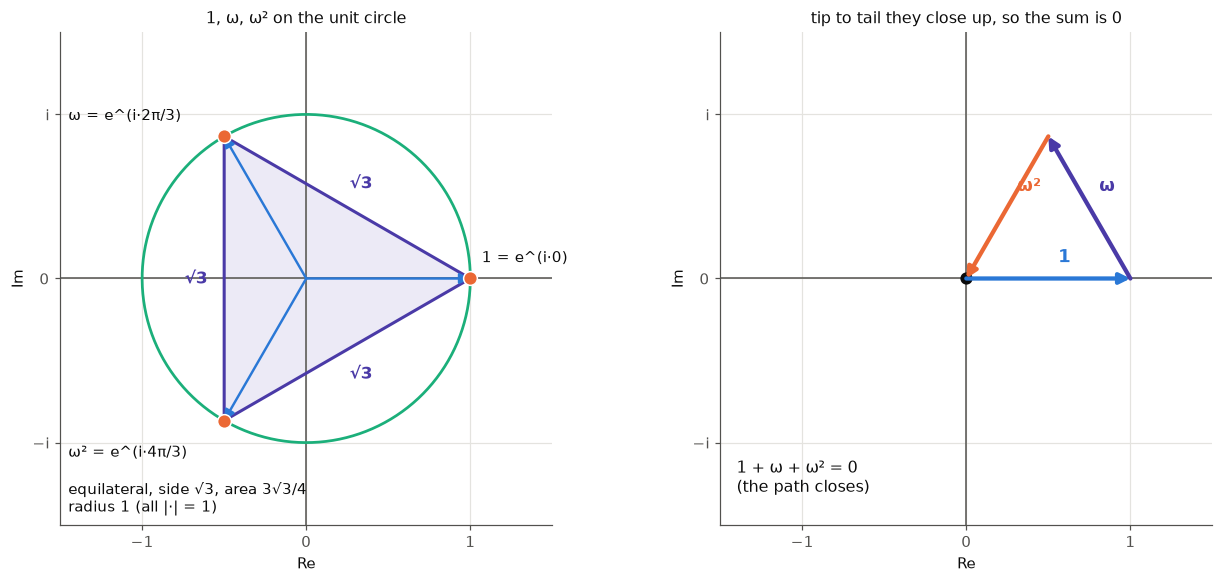

In [9]:
# Static summary of the geometry: unit circle, equilateral triangle, GP / AP, 1 + ω + ω² = 0
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
ax = axes[0]; argand(ax, lim=1.5); unit_circle(ax, color=AQUA, lw=1.8)
ax.fill([r.real for r in ROOTS], [r.imag for r in ROOTS], color=VIOLET, alpha=0.1)
ax.plot([r.real for r in ROOTS + [ROOTS[0]]], [r.imag for r in ROOTS + [ROOTS[0]]], color=VIOLET, lw=2)
for k, (r, lab) in enumerate(zip(ROOTS, ["1 = e^(i·0)", "ω = e^(i·2π/3)", "ω² = e^(i·4π/3)"])):
    arrow(ax, 0, r, BLUE, 1.6)
    ax.plot(r.real, r.imag, "o", color=ORANGE, ms=9, mec="white", zorder=5)
    ax.text(r.real + (0.07 if k == 0 else -0.95), r.imag + (0.1 if k < 2 else -0.22), lab, color=INK, fontsize=9.5)
for k in range(3):
    m = (ROOTS[k] + ROOTS[(k + 1) % 3])/2; m = m + 0.17*m/abs(m)   # nudge outward, away from the side
    ax.text(m.real, m.imag, "√3", color=VIOLET, fontsize=11, weight="bold", ha="center", va="center")
ax.text(-1.45, -1.42, "equilateral, side √3, area 3√3/4\nradius 1 (all |·| = 1)", fontsize=9.5)
ax.set_title("1, ω, ω² on the unit circle", fontsize=10.5)
ax = axes[1]; argand(ax, lim=1.5)
pos = 0j
for z, c, lab in zip(ROOTS, [BLUE, VIOLET, ORANGE], ["1", "ω", "ω²"]):
    arrow(ax, pos, pos + z, c, 2.8); m = pos + z/2
    ax.text(m.real + 0.06, m.imag + 0.1, lab, color=c, fontsize=12, weight="bold"); pos += z
ax.plot(0, 0, "o", color=INK, ms=7)
ax.text(-1.4, -1.3, "1 + ω + ω² = 0\n(the path closes)", fontsize=10.5)
ax.set_title("tip to tail they close up, so the sum is 0", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## 6. Cube Factorisations Using $\omega$

$$\boxed{a^3 + b^3 = (a + b)(a + b\omega)(a + b\omega^2)}$$
$$\boxed{a^3 - b^3 = (a - b)(a - b\omega)(a - b\omega^2)}$$
$$\boxed{a^3 + b^3 + c^3 - 3abc = (a + b + c)(a + b\omega + c\omega^2)(a + b\omega^2 + c\omega)}$$

### Proof of the first (from the lecture)
Start from the usual factorisation:
$$a^3 + b^3 = (a + b)(a^2 - ab + b^2)$$
Now use two "harmless" substitutions:
- $-1 = \omega + \omega^2$ (from $1 + \omega + \omega^2 = 0$), so $-ab = (\omega + \omega^2)ab$;
- $1 = \omega^3$, so $b^2 = \omega^3 b^2$. *"If I write it, can you stop me? It's true!"*

$$a^2 - ab + b^2 = a^2 + \omega ab + \omega^2 ab + \omega^3 b^2$$
Group in pairs:
$$= a(a + \omega b) + \omega^2 b(a + \omega b) = (a + \omega b)(a + \omega^2 b)$$
$$\Longrightarrow\; a^3 + b^3 = (a + b)(a + b\omega)(a + b\omega^2) \quad\blacksquare$$

**Homework from the lecture:** prove the other two the same way. A hint for the third: expand the product of the last two brackets and use $\omega + \omega^2 = -1$ and $\omega^3 = 1$. You should get $a^2 + b^2 + c^2 - ab - bc - ca$, then use the standard identity.

> The lecturer recommends **memorising** all three identities. Good JEE students keep these at their fingertips.

In [10]:
a, b, c = rng.normal(size=(3, 100_000)) + 1j*rng.normal(size=(3, 100_000))
check = lambda name, L, R: print(f"{name}: holds on {np.isclose(L, R).mean()*100:.2f}% of 100,000 random (complex) a, b, c")
check("a³ + b³ = (a + b)(a + bω)(a + bω²)            ", a**3 + b**3, (a + b)*(a + b*w)*(a + b*w**2))
check("a³ − b³ = (a − b)(a − bω)(a − bω²)            ", a**3 - b**3, (a - b)*(a - b*w)*(a - b*w**2))
check("a³+b³+c³−3abc = (a+b+c)(a+bω+cω²)(a+bω²+cω)  ", a**3 + b**3 + c**3 - 3*a*b*c, (a + b + c)*(a + b*w + c*w**2)*(a + b*w**2 + c*w))

a³ + b³ = (a + b)(a + bω)(a + bω²)            : holds on 100.00% of 100,000 random (complex) a, b, c
a³ − b³ = (a − b)(a − bω)(a − bω²)            : holds on 100.00% of 100,000 random (complex) a, b, c
a³+b³+c³−3abc = (a+b+c)(a+bω+cω²)(a+bω²+cω)  : holds on 100.00% of 100,000 random (complex) a, b, c


---
## 7. Square Roots, Fourth Roots, and $n$-th Roots of Unity

**Square roots of unity:** $x^2 = 1$ gives $(x - 1)(x + 1) = 0$, so $x = \pm1$. Two roots. $+1$ is called the **principal square root**.

**Fourth roots of unity:** $x^4 = 1$ gives $(x^2 - 1)(x^2 + 1) = 0$, so $x = \pm1$ or $x^2 = -1$, which means $x = \pm i$. Four roots: $1, -1, i, -i$.

**The pattern:**
| $1^{1/n}$ | number of values |
|---|---|
| $1^{1/2}$ | 2 |
| $1^{1/3}$ | 3 |
| $1^{1/4}$ | 4 |
| $1^{1/n}$ | **$n$ different values** |

The $n$-th roots of unity are the main topic of the **next lecture**. The lecturer advises getting all of today's properties firmly in memory first.

### Preview *(extra)*: they always form a regular polygon
The $n$-th roots of unity are $e^{2\pi ik/n}$ for $k = 0, 1, \dots, n - 1$. These are $n$ points equally spaced around the unit circle, the vertices of a **regular $n$-gon**, always including $1$. For $n = 3$, it's our equilateral triangle.

n = 2: roots [ 1.+0.j -1.+0.j]   sum = 0j
n = 3: roots [ 1. +0.j    -0.5+0.866j -0.5-0.866j]   sum = (-0+0j)
n = 4: roots [ 1.+0.j  0.+1.j -1.+0.j -0.-1.j]   sum = (-0+0j)
n = 5: roots [ 1.   +0.j     0.309+0.951j -0.809+0.588j -0.809-0.588j  0.309-0.951j]   sum = (-0+0j)
n = 6: roots [ 1. +0.j     0.5+0.866j -0.5+0.866j -1. +0.j    -0.5-0.866j  0.5-0.866j]   sum = (-0+0j)


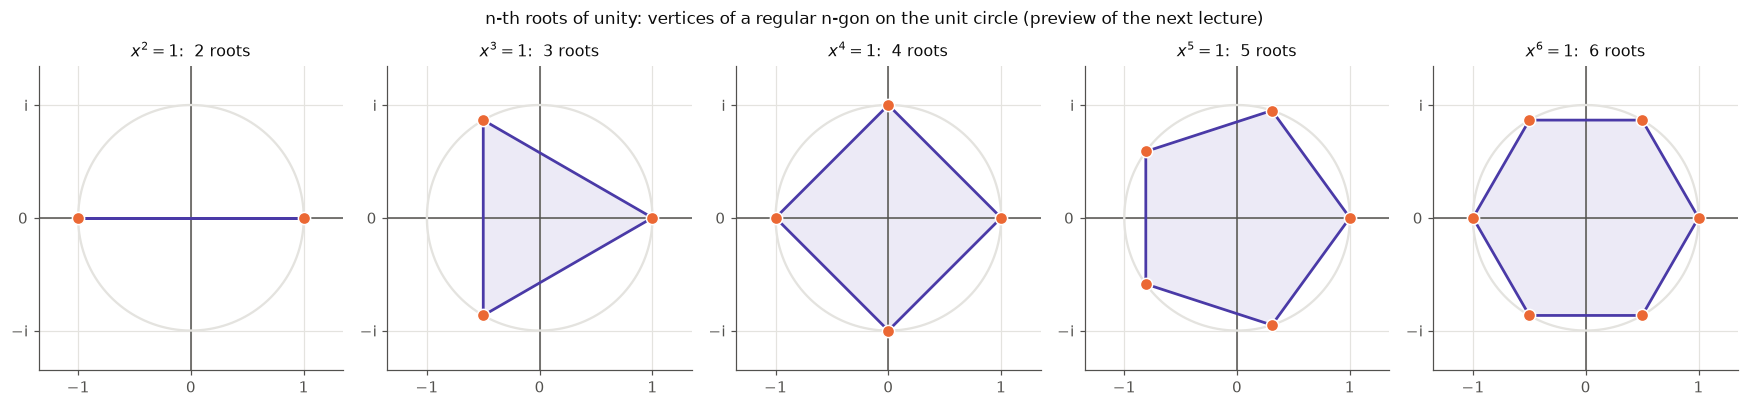

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6))
for ax, n in zip(axes, [2, 3, 4, 5, 6]):
    argand(ax, lim=1.35); unit_circle(ax); ax.set_xlabel(""); ax.set_ylabel("")
    R = np.exp(2j*np.pi*np.arange(n)/n)
    if n > 2: ax.fill(R.real, R.imag, color=VIOLET, alpha=0.1)
    ax.plot(np.r_[R.real, R.real[0]], np.r_[R.imag, R.imag[0]], color=VIOLET, lw=1.8)
    ax.plot(R.real, R.imag, "o", color=ORANGE, ms=8, mec="white", zorder=5)
    ax.set_title(f"$x^{n} = 1$:  {n} roots", fontsize=10.5)
    print(f"n = {n}: roots", np.round(R, 3), "  sum =", np.round(R.sum(), 12))
fig.suptitle("n-th roots of unity: vertices of a regular n-gon on the unit circle (preview of the next lecture)", fontsize=11)
plt.tight_layout(); plt.show()

---
## 8. Question: Sum of a Series with $\omega$

**Q.** Find the sum of the series
$$1\cdot(2 - \omega)(2 - \omega^2) + 2\cdot(3 - \omega)(3 - \omega^2) + \cdots + (n - 1)\cdot(n - \omega)(n - \omega^2)$$
where $\omega$ is an imaginary cube root of unity.

**Step 1: the general term.** The $r$-th bracket pattern is $(r - 1)(r - \omega)(r - \omega^2)$, for $r = 2, 3, \dots, n$. Including $r = 1$ adds nothing, since that term is $0$.

**Step 2: simplify $(r - \omega)(r - \omega^2)$.**
$$(r - \omega)(r - \omega^2) = r^2 - r(\omega + \omega^2) + \omega^3 = r^2 - r(-1) + 1 = r^2 + r + 1$$
**Step 3: so the general term is a familiar factorisation.**
$$T_r = (r - 1)(r^2 + r + 1) = r^3 - 1$$
*(This is just the $a^3 - b^3$ identity in reverse. The $\omega$'s have disappeared.)*

**Step 4: sum using standard results** (from sequences and series):
$$S = \sum_{r=1}^{n}(r^3 - 1) = \sum r^3 - \sum 1 = \left[\frac{n(n + 1)}{2}\right]^2 - n$$
$$\boxed{S = \frac{n^2(n + 1)^2}{4} - n}$$

> The two tools: $\omega + \omega^2 = -1$ and $\omega^3 = 1$ to kill the $\omega$'s, then $\sum r^3 = \left(\frac{n(n+1)}{2}\right)^2$. If the $\Sigma$ formulas are new to you, don't worry. They're covered in detail in the sequences and series chapter.

In [12]:
def S_direct(n):
    return sum((r - 1)*(r - w)*(r - w**2) for r in range(2, n + 1))
print(" n | direct sum (with ω)        | n²(n+1)²/4 − n")
for n in [2, 3, 4, 5, 10, 25]:
    d = S_direct(n)
    print(f"{n:>2} | {d.real:>14.6f} {d.imag:+.1e}i | {n**2*(n + 1)**2/4 - n:>14.6f}")
print("\n(r − ω)(r − ω²) = r² + r + 1 ?", all(np.isclose((r - w)*(r - w**2), r*r + r + 1) for r in range(-5, 20)))

 n | direct sum (with ω)        | n²(n+1)²/4 − n
 2 |       7.000000 +1.1e-16i |       7.000000
 3 |      33.000000 -1.1e-16i |      33.000000
 4 |      96.000000 -1.1e-15i |      96.000000
 5 |     220.000000 -1.6e-15i |     220.000000
10 |    3015.000000 +4.1e-15i |    3015.000000
25 |  105600.000000 +8.4e-15i |  105600.000000

(r − ω)(r − ω²) = r² + r + 1 ? True


**Homework from the lecture:** one more question was set on screen ("solve and comment the answer"). Its wording can't be recovered from the captions, so check the video near 52:00. The lecturer will discuss it next time.

---
## Summary

| Idea | Result |
|---|---|
| Cube roots of unity | $x^3 = 1 \Rightarrow 1,\ \omega = \frac{-1 + \sqrt3 i}{2},\ \omega^2 = \frac{-1 - \sqrt3 i}{2}$ (one real, two imaginary) |
| Naming | either imaginary root is $\omega$, and the other is then $\omega^2$ |
| Conjugates | $\bar\omega = \omega^2$, $\overline{\omega^2} = \omega$ |
| Modulus | $\lvert1\rvert = \lvert\omega\rvert = \lvert\omega^2\rvert = 1$ |
| Key identities | $1 + \omega + \omega^2 = 0$, $\;\omega^3 = 1$, $\;\omega^{3k} = 1$, $\;\omega^n = \omega^{n \bmod 3}$ |
| Power sums | $1 + \omega^p + \omega^{2p} = 3$ if $3 \mid p$, otherwise $0$ |
| Geometry | unit circle, equilateral triangle with side $\sqrt3$ and area $\frac{3\sqrt3}{4}$. Roots in GP, args $0, \frac{2\pi}{3}, \frac{4\pi}{3}$ in AP |
| Factorisations | $a^3 \pm b^3 = (a \pm b)(a \pm b\omega)(a \pm b\omega^2)$, $\;a^3 + b^3 + c^3 - 3abc = (a + b + c)(a + b\omega + c\omega^2)(a + b\omega^2 + c\omega)$ |
| Other roots | $1^{1/2} = \pm1$, $\;1^{1/4} = \pm1, \pm i$, $\;1^{1/n}$ has $n$ values (next lecture) |

---
## Practice *(extra)*
1. Find $\omega^{100} + \omega^{200} + 1$.
2. Simplify $(1 + \omega - \omega^2)(1 - \omega + \omega^2)$.
3. Find $(1 - \omega + \omega^2)^5 + (1 + \omega - \omega^2)^5$.
4. Show that $\dfrac{a + b\omega + c\omega^2}{c + a\omega + b\omega^2} = \omega^2$ for any $a, b, c$ (with nonzero denominator).
5. Factorise $x^3 + 8$ into linear factors.

<details>
<summary>Answers (open after attempting)</summary>

1. $100 = 3\cdot33 + 1$, so this is $1 + \omega^{100} + \omega^{200}$ with $p = 100$, not a multiple of 3. Answer: $0$.
2. $1 + \omega = -\omega^2$ and $1 + \omega^2 = -\omega$, so the product is $(-2\omega^2)(-2\omega) = 4\omega^3 = 4$.
3. $(-2\omega)^5 + (-2\omega^2)^5 = -32(\omega^5 + \omega^{10}) = -32(\omega^2 + \omega) = 32$.
4. $\omega^2(c + a\omega + b\omega^2) = c\omega^2 + a\omega^3 + b\omega^4 = a + b\omega + c\omega^2$, using $\omega^3 = 1$ and $\omega^4 = \omega$. So the denominator times $\omega^2$ equals the numerator, and the ratio is $\omega^2$.
5. $x^3 + 2^3 = (x + 2)(x + 2\omega)(x + 2\omega^2)$.
</details>

In [13]:
# Checks for the practice set
print("1:", np.round(w**100 + w**200 + 1, 12) + 0)
print("2:", np.round((1 + w - w**2)*(1 - w + w**2), 12))
print("3:", np.round((1 - w + w**2)**5 + (1 + w - w**2)**5, 9))
a, b, c = rng.normal(size=3) + 1j*rng.normal(size=3)
r = (a + b*w + c*w**2)/(c + a*w + b*w**2)
print("4: ratio =", np.round(r, 12), "  ω² =", np.round(w**2, 6), "→ equal:", np.isclose(r, w**2))
print("5: roots of x³ + 8:", np.round(np.roots([1, 0, 0, 8]), 6), "  vs −2, −2ω, −2ω²:", np.round([-2, -2*w, -2*w**2], 6))

1: 0j
2: (4+0j)
3: (32+0j)
4: ratio = (-0.5-0.866025403784j)   ω² = (-0.5-0.866025j) → equal: True
5: roots of x³ + 8: [-2.+0.j        1.+1.732051j  1.-1.732051j]   vs −2, −2ω, −2ω²: [-2.+0.j        1.-1.732051j  1.+1.732051j]
